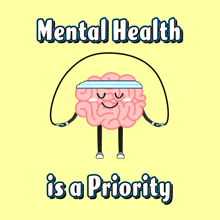

# 🧠 **MindWell - Mental Health Score Predictor**

### **Project Overview**:
This project analyzes the relationship between students' social media usage, lifestyle habits, sleep patterns, study behavior, physical activity, and mental health.

The objective is to build a Machine Learning model that can predict a student's **Mental Health Score** based on relevant behavioral and lifestyle factors.

### **Problem Statement**:

The increasing use of social media has significantly influenced students' daily routines, including their sleep, study habits, physical activity, and overall well-being.

Can a student's social media usage, sleep, study habits, physical activity, and other behavioral characteristics be used to predict their **Mental Health Score**?

To answer this question, we will use **Student Social Media and Mental Health Impact Dataset**.

### **Dataset Information:**
The Student Social Media and Mental Health Impact Dataset is a behavioral analytics dataset containing 5,000 student records designed to explore the relationship between social media usage, lifestyle habits, and mental well-being.

**Features**
- Age – Student age
- Gender – Gender of the student
- Country – Country of residence
- Academic_Level – Educational level of the student
- Most_Used_Platform – Primary social media platform used
- Purpose_Of_Use – Main purpose of social media usage
- Avg_Daily_Usage_Hours – Average hours spent daily on social media
- Daily_Unlocks – Estimated number of device unlocks per day
- Study_Hours – Average study time per day
- Physical_Activity_Hours – Daily physical activity duration
- Sleep_Hours_Per_Night – Average sleep duration per night
- Stress_Level – Self-reported stress category
- Mental_Health_Score – Mental well-being score

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2.  Load the Dataset

In [3]:
df = pd.read_csv('../dataset/Student Social Media And Mental Health Impact.csv')

## 3. Exploratory Data Analysis (EDA)

In [4]:
# Check first five rows of the dataset
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [11]:
# Check shape of the dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 5000
Number of Columns: 13


In [12]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [13]:
# Check statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,20.82180,1.736620,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,5000.0,5.07846,1.653913,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,5000.0,171.45260,42.858254,62.0,140.0,171.0,204.0,273.0
Study_Hours,5000.0,3.00842,1.637018,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,5000.0,1.75100,0.668398,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,5000.0,6.63458,1.221391,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,5000.0,6.23098,1.278701,3.6,5.1,6.1,7.1,9.4


In [14]:
# Check missing values
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [5]:
# Check duplicate values
print(df.duplicated().sum())

2


In [14]:
print(pd.__version__)

3.0.5


In [15]:
# Check categorical columns unique items
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f'{col}\n{df[col].unique()}')
    print('-' * 40, '\n')

Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
---------------------------------------- 

Country
<StringArray>
[      'Other',      'Canada',         'USA',       'India',   'Australia',
          'UK',     'Germany',  'Bangladesh',      'Brazil',       'Japan',
 ...
     'Lebanon',        'Iraq',       'Yemen',       'Syria', 'Afghanistan',
    'Pakistan',       'Nepal',      'Bhutan',   'Sri Lanka',    'Maldives']
Length: 111, dtype: str
---------------------------------------- 

Academic_Level
<StringArray>
['Undergraduate', 'Graduate', 'High School']
Length: 3, dtype: str
---------------------------------------- 

Most_Used_Platform
<StringArray>
[ 'Facebook',  'LinkedIn', 'Instagram',  'Snapchat',   'Twitter',   'YouTube',
    'TikTok',      'LINE', 'KakaoTalk', 'VKontakte',  'WhatsApp',    'WeChat']
Length: 12, dtype: str
---------------------------------------- 

Purpose_Of_Use
<StringArray>
['Networking', 'Education', 'Entertainment', 'News']
Length: 4, dtype: s

## Visualization

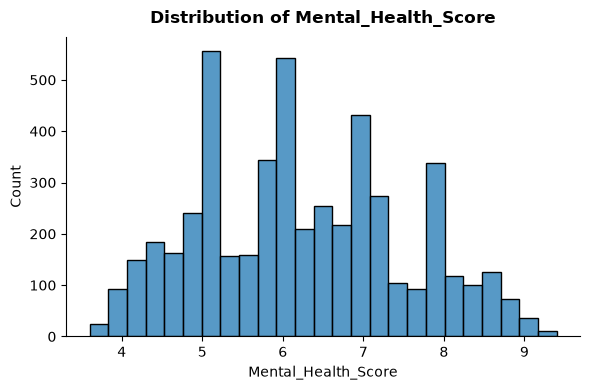

In [17]:
# Check distribution of the target column - Mental_Health_Score
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Mental_Health_Score')
plt.title('Distribution of Mental_Health_Score',fontweight='bold',pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Distribution of Mental_Health_Score.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

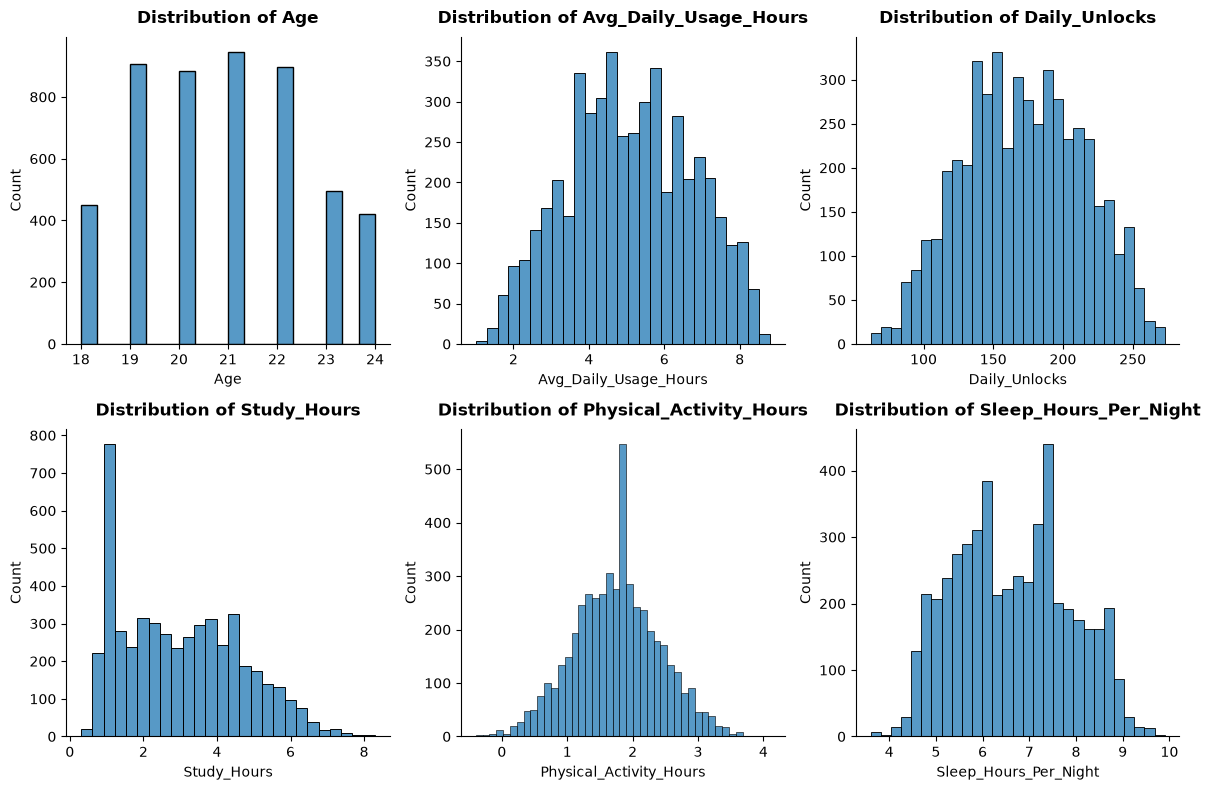

In [7]:
# Check distribution of other numerical columns
num_col = ['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

plt.figure(figsize=(12, 8))
for i,col in enumerate(num_col, 1):
  plt.subplot(2,3,i)
  sns.histplot(data=df, x=col)
  plt.title(f'Distribution of {col}', fontweight='bold', pad=10)
  plt.xlabel(col)
  sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Numerical_Column_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
# Check frequency distribution of all categorical columns
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f'{df[col].value_counts()}')
    print('-' * 40, '\n')

Gender
Male      2635
Female    2365
Name: count, dtype: int64
---------------------------------------- 

Country
Other         1880
India          389
USA            355
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64
---------------------------------------- 

Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64
---------------------------------------- 

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64
---------------------------------------- 

Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64
------------

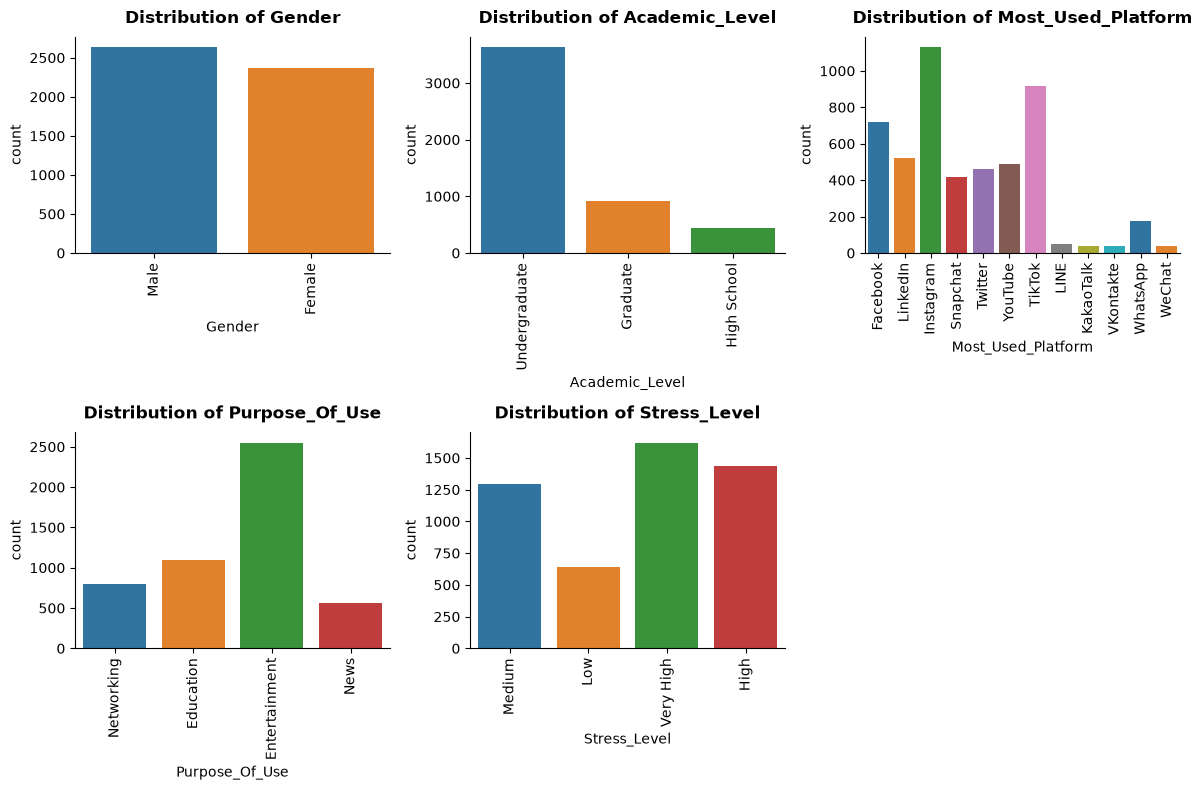

In [ ]:
# Check distribution of categorical columns, excluding Country due to its large number of categories
cat_col = [col for col in df.columns if df[col].dtype == 'str' and col!='Country']

plt.figure(figsize=(12, 8))
for i,col in enumerate(cat_col, 1):
  plt.subplot(2,3,i)
  sns.countplot(data=df, x=col, palette='tab10')
  plt.title(f'Distribution of {col}', fontweight='bold', pad=10)
  plt.xlabel(col)
  plt.xticks(rotation=90)
  sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Categorical_Column_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

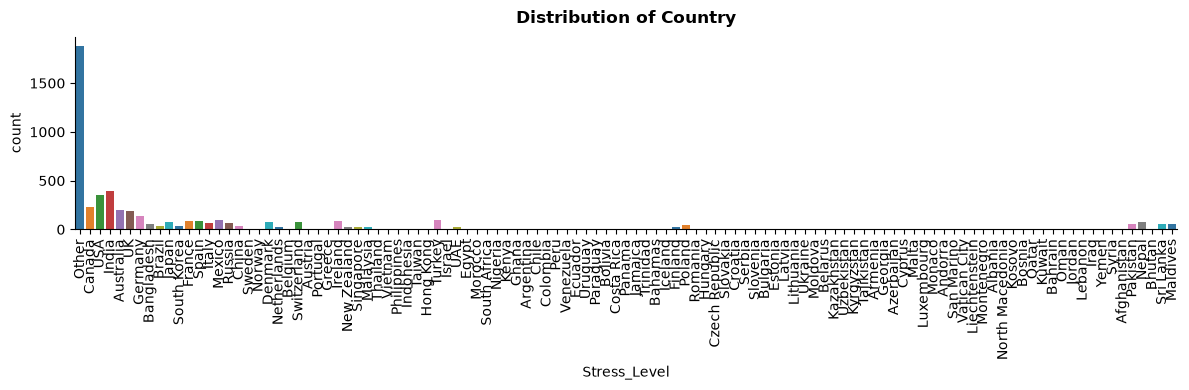

In [32]:
# Check distribution of Country
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='Country', palette='tab10')
plt.title(f'Distribution of Country', fontweight='bold', pad=10)
plt.xlabel(col)
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Country_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()